# MODELO DE CLASIFICACIÓN DE IMAGENES PARA DETERMINAR NEUMONIA EN PACIENTES CON COVID 19 USANDO REDES NEURONALES CONVOLUCIONALES CON PYTORCH

## DATASET  [KAGGLE](https://www.kaggle.com/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/data)

# 1 - IMPORTAMOS LIBRERIAS

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn

import torchvision
from torchvision import datasets, models, transforms

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy

# 2 - CARGAMOS DATASET

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_dir = '/content/drive/MyDrive/CODIGOG7/MODULO6/TRABAJOFINAL/datasets'

# 3 - HABILITAR USO DE GPU(CUDA)

In [4]:
cudnn.benchmark = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

# 4 - APLICAR DATA AUGMENTATION

In [5]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'validation': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 5 - APLICAMOS TRANSFORMACIONES SOBRE LAS IMAGENES

In [6]:
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])for x in ['train', 'validation']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=2) for x in ['train', 'validation']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'validation']}

class_names = image_datasets['train'].classes

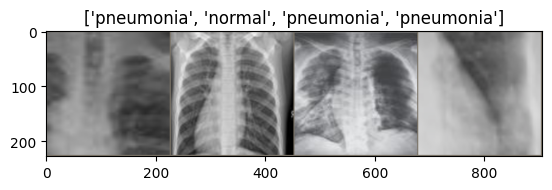

In [7]:
def imshow(inp, title=None):
    """Imshow para tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # Pausarlo un poco para que se actualicen los plots


# Obtener un batch de datos de entrenamiento
inputs, classes = next(iter(dataloaders['train']))

# Crear una grilla con las imágenes
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [8]:
print(class_names)

['normal', 'pneumonia']


# 6 - CREAMOS RED NEURONAL CONVOLUCIONAL CON PYTORCH

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        # Primera capa convolucional
        # Imagen RGB → 8 mapas de características
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Segunda capa convolucional
        # 8 mapas → 16 mapas
        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Tercera capa convolucional
        # 16 mapas → 32 mapas
        self.conv3 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Capa fully connected
        # Después de 3 poolings:
        # 224 → 112 → 56 → 28
        self.fc1 = nn.Linear(32 * 28 * 28, 64)

        # Capa de salida
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):

        # Bloque 1
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)

        # Bloque 2
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Bloque 3
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2, 2)

        # Aplanar tensor
        x = torch.flatten(x, start_dim=1)

        # Capas fully connected
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [10]:
model_ft = CNN().to(device)

# 7 - ENTRENAMOS LA RED NEURONAL

In [11]:
import time, copy
import torch

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Guardaremos métricas aquí (tipo Keras)
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Cada epoch tiene entrenamiento y validación
        for phase in ['train', 'validation']:

            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data).item()

            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # Guardar métricas en history
            if phase == 'train':
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc)
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc)

                # Guardar mejor modelo según val acc
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    model.load_state_dict(best_model_wts)

    # devolvemos model y history para graficar
    return model, history

In [12]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['validation']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [13]:
criterion = nn.CrossEntropyLoss()

# Observe que todos los parámetros están siendo optimizados
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decae LR por un factor de 0.1 cada 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [14]:
model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------
train Loss: 0.6993 Acc: 0.5338
validation Loss: 0.6775 Acc: 0.8148

Epoch 1/9
----------
train Loss: 0.6799 Acc: 0.6892
validation Loss: 0.6443 Acc: 0.8333

Epoch 2/9
----------
train Loss: 0.6462 Acc: 0.6757
validation Loss: 0.5890 Acc: 0.7222

Epoch 3/9
----------
train Loss: 0.5337 Acc: 0.7770
validation Loss: 0.6935 Acc: 0.7037

Epoch 4/9
----------
train Loss: 0.5684 Acc: 0.7500
validation Loss: 0.3587 Acc: 0.9074

Epoch 5/9
----------
train Loss: 0.4515 Acc: 0.7905
validation Loss: 0.2765 Acc: 0.9074

Epoch 6/9
----------
train Loss: 0.5382 Acc: 0.7703
validation Loss: 0.2980 Acc: 0.9074

Epoch 7/9
----------
train Loss: 0.4155 Acc: 0.8243
validation Loss: 0.2773 Acc: 0.9074

Epoch 8/9
----------
train Loss: 0.3752 Acc: 0.8851
validation Loss: 0.2622 Acc: 0.9074

Epoch 9/9
----------
train Loss: 0.4716 Acc: 0.7838
validation Loss: 0.2702 Acc: 0.8889

Training complete in 0m 49s
Best val Acc: 0.907407


In [15]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history["train_acc"]) + 1)

    # Accuracy
    plt.plot(epochs, history["train_acc"], 'bo', label='Training Acc')
    plt.plot(epochs, history["val_acc"], 'b', label='Validation Acc')
    plt.title('Precisión en validación y entrenamiento')
    plt.legend()
    plt.show()

    # Loss
    plt.plot(epochs, history["train_loss"], 'bo', label='Training Loss')
    plt.plot(epochs, history["val_loss"], 'b', label='Validation Loss')
    plt.title('Pérdida en validación y entrenamiento')
    plt.legend()
    plt.show()

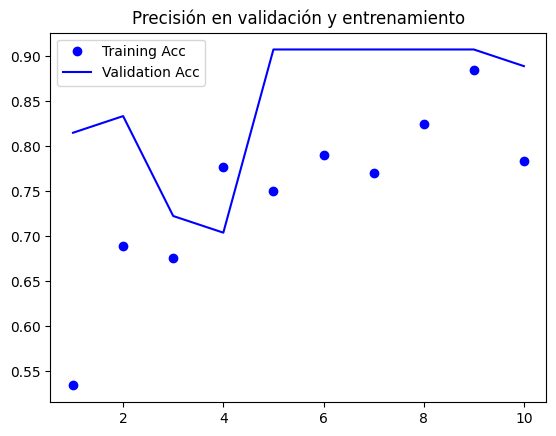

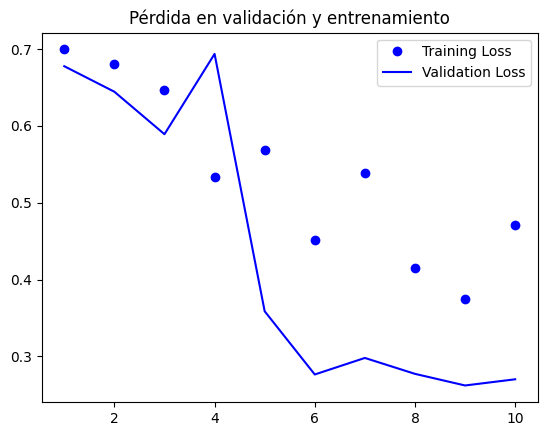

In [16]:
plot_history(history)

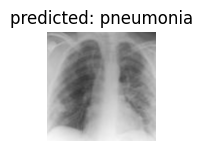

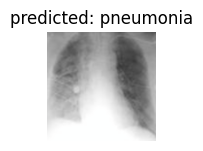

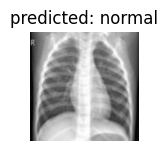

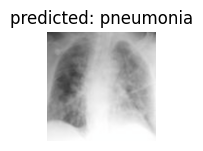

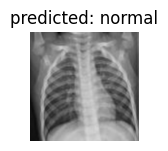

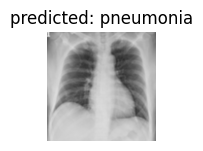

In [17]:
visualize_model(model_ft)

# 8 - GUARDAMOS EL MODELO

In [18]:
torch.save(model_ft.state_dict(), "model_neumonia.pth")